In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from keras.datasets import mnist
import cv2
np.random.seed(42)

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = np.array([cv2.resize(i, (32,32)) for i in x_train])
x_test = np.array([cv2.resize(i, (32,32)) for i in x_test])

In [6]:
############# Simulating Training/Testing Data #####################
def get_binary_mask(image):
    mask = np.copy(image)
    mask[mask>0.1]=1
    mask[mask!=1]=0
    return mask    

def get_bounding_box(binary_image):
    rows, cols = np.where(binary_image == 1)
    x1 = cols.min()
    x2 = cols.max()
    y1 = rows.min()
    y2 = rows.max()
    x_c = (x1+x2)/2
    y_c = (y1+y2)/2    
    w = x2-x1
    h = y2-y1       
    return [x_c, y_c, w, h]

def mnist_detection(x_train,y_train,number_of_instances): 
    if number_of_instances>64:
        number_of_instances = 64
    idx = np.random.choice(np.arange(len(x_train)), number_of_instances)
    imgs = x_train[idx]
    msks = np.array([get_binary_mask(i) for i in imgs])
    classes = y_train[idx]
    
    x,y = np.meshgrid(np.arange(0,256,32),np.arange(0,256,32))
    possible_choices = []
    for i in range(x.shape[0]):
        for j in range(x.shape[1]):
            possible_choices.append([x[0,i],y[j,0]])
    possible_choices = np.array(possible_choices)        
    
    choices = np.random.choice(len(possible_choices), number_of_instances, replace = False)
    choices = possible_choices[choices,:]  
    
    img = np.zeros((256,256))
    bboxes = np.zeros((number_of_instances,5))
    
    for k in range(number_of_instances):
        x_i = choices[k,0]
        y_i = choices[k,1]
        x_f = x_i + 32
        y_f = y_i + 32
        img[x_i:x_f,y_i:y_f] = imgs[k]
        
        bbox = get_bounding_box(msks[k])
        bbox[0] += y_i
        bbox[1] += x_i
        bboxes[k,:] = np.hstack([bbox,classes[k]])
    
    gaussian_noise = np.random.normal(0, 127.5, img.shape).astype(np.float32)
    noisy_img = img.astype(np.float32) + gaussian_noise
    noisy_img = np.clip(noisy_img, 0, 255).astype(np.uint8)    
    blurred_img = cv2.GaussianBlur(noisy_img, (1, 1), sigmaX=0)    
    return blurred_img, bboxes

def plot_img_bboxes(img, bboxes):
    fig, ax = plt.subplots()
    ax.imshow(img)
    for bbox in bboxes:
        x_c, y_c, w, h = bbox[:4]
        rect = patches.Rectangle((x_c-w/2, y_c-h/2), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)  
        plt.text(x_c+w/2,y_c+h/2,str(int(bbox[-1])), c = 'w', fontsize = 16)

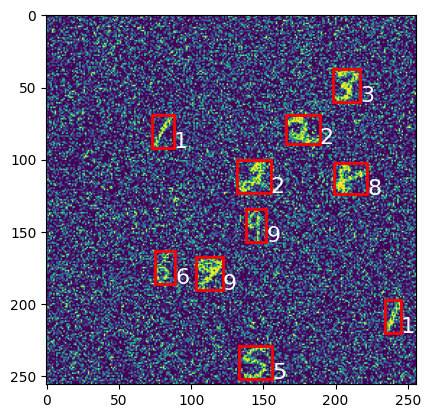

In [7]:
########## Example ###########
number_of_instances = 10
img, bboxes = mnist_detection(x_train,y_train,number_of_instances)
plot_img_bboxes(img, bboxes)

In [8]:
############## Create Training/Testing Data ##############
number_of_instances = np.arange(0,30)
train = [mnist_detection(x_train,y_train,np.random.choice(number_of_instances)) for i in range(1000)]
train_imgs = np.array([np.expand_dims(i[0], axis = -1)/255.0 for i in train])
train_bboxes = [i[1] for i in train]
del train

test = [mnist_detection(x_train,y_train,np.random.choice(number_of_instances)) for i in range(100)]
test_imgs = np.array([np.expand_dims(i[0], axis = -1)/255.0 for i in test])
test_bboxes = [i[1] for i in test]
del test
del x_train, y_train, x_test, y_test,number_of_instances


In [9]:
############## Training/Testing Data for Yolo Model ##############
def convert_bboxes_to_yolo_image(bboxes):
    image_size = 256 # input image size to yolo model (256*256)
    patch_size = 8 # yolo patch size, output layer (8*8)
    no_of_classes = 10 # number of object classes
    scale = image_size/patch_size    
    
    if bboxes.shape[0]>0:
        bboxes_resized = bboxes[:,:4]/scale
    
        positions = np.floor(bboxes_resized[:,:2])
        bboxes_resized[:,:2] = bboxes_resized[:,:2]-positions
        positions = positions.astype('uint8')     
    
        yolo_img = np.zeros((patch_size,patch_size,5+no_of_classes+1))
        yolo_img[positions[:,1],positions[:,0],0] = 1
        yolo_img[positions[:,1],positions[:,0],1] = bboxes_resized[:,0]
        yolo_img[positions[:,1],positions[:,0],2] = bboxes_resized[:,1]
        yolo_img[positions[:,1],positions[:,0],3] = bboxes_resized[:,2]
        yolo_img[positions[:,1],positions[:,0],4] = bboxes_resized[:,3]
        for i in range(bboxes.shape[0]):
            yolo_img[positions[i,1],positions[i,0],5+int(bboxes[i,-1])] = 1
        temp = np.copy(yolo_img[:,:,0])
        temp[temp==1] = -1
        temp[temp==0] = 1
        temp[temp==-1] = 0
        yolo_img[:,:,-1] = temp
    else:
        yolo_img = np.zeros((patch_size,patch_size,5+no_of_classes+1))
        temp = np.copy(yolo_img[:,:,0])
        yolo_img[:,:,-1] = 1
    return yolo_img

def extract_bboxes_from_yolo_image(yolo_img):
    image_size = 256 # input image size to yolo model (256*256)
    patch_size = 8 # yolo patch size, output layer (8*8)    
    scale = image_size/patch_size    
    
    bf_image = np.copy(yolo_img[:,:,0])
    p_image = np.copy(yolo_img[:,:,0])
    
    bf_image[bf_image<0.5]=0
    bf_image[bf_image>=0.5]=1
    ixy = np.argwhere(bf_image==1)
    bboxes = []
    for i in range(ixy.shape[0]):
        i_x = ixy[i,1]
        i_y = ixy[i,0]
        x_c = (yolo_img[i_y,i_x,1]+i_x)*scale
        y_c = (yolo_img[i_y,i_x,2]+i_y)*scale
        w = yolo_img[i_y,i_x,3]*scale
        h = yolo_img[i_y,i_x,4]*scale  
        p = p_image[i_y,i_x]
        c = np.argmax(yolo_img[i_y,i_x,5:-1])
        bboxes.append([x_c,y_c,w,h,p,c.astype('uint8')])
    return np.array(bboxes)

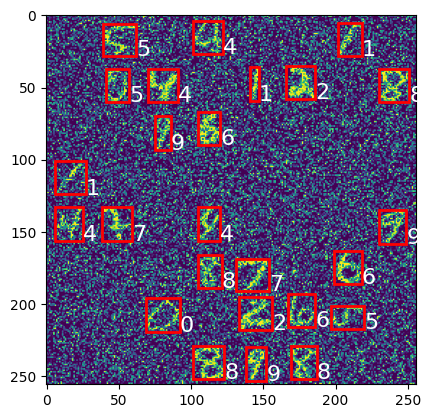

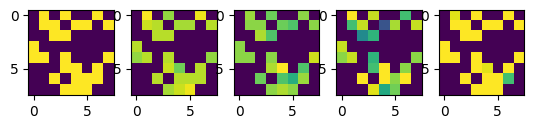

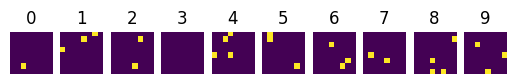

In [18]:
img = train_imgs[0]
bboxes = train_bboxes[0]
plot_img_bboxes(img,bboxes)

yolo_img = convert_bboxes_to_yolo_image(bboxes)

plt.figure()
plt.subplot(1,5,1)
plt.imshow(yolo_img[:,:,0]) # background/foreground
plt.subplot(1,5,2)
plt.imshow(yolo_img[:,:,1]) # x_c
plt.subplot(1,5,3)
plt.imshow(yolo_img[:,:,2]) # y_c
plt.subplot(1,5,4)
plt.imshow(yolo_img[:,:,3]) # width
plt.subplot(1,5,5)
plt.imshow(yolo_img[:,:,4]) #height

plt.figure()
for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(yolo_img[:,:,5+i]) # classes
    plt.axis('off')
    plt.title(str(i))

bboxes_yolo = extract_bboxes_from_yolo_image(yolo_img)


In [19]:
###### yolo model training labels ######
train_yolo = [convert_bboxes_to_yolo_image(i) for i in train_bboxes]
train_yolo_bf = np.array([np.expand_dims(i[:,:,0], axis = -1) for i in train_yolo])
train_yolo_p = np.array([i[:,:,1:5] for i in train_yolo])
train_yolo_c = np.array([i[:,:,5:] for i in train_yolo])


In [20]:
########### yolo model ############
from tensorflow.keras import layers, models
def yolo_model():
    input_img = layers.Input(shape=(256,256,1))
    
    # Encoder (Downsampling)
    c1 = layers.Conv2D(8, 3, strides=2, padding='same', activation = 'relu')(input_img) #128
    c1 = layers.Dropout(0.4)(c1)

    c2 = layers.Conv2D(16, 3, strides=2, padding='same', activation = 'relu')(c1) # 64
    c2 = layers.Dropout(0.4)(c2)

    c3 = layers.Conv2D(32, 3, strides=2, padding='same', activation = 'relu')(c2) # 32
    c3 = layers.Dropout(0.4)(c3)

    c4 = layers.Conv2D(64, 3, strides=2, padding='same', activation = 'relu')(c3) # 16
    c4 = layers.Dropout(0.4)(c4)

    c5 = layers.Conv2D(128, 3, strides=2, padding='same', activation = 'relu')(c4) # 8
    c5 = layers.Dropout(0.4)(c5)

    c6 = layers.Conv2D(256, 3, strides=2, padding='same', activation = 'relu')(c5) # 4
    c6 = layers.Dropout(0.4)(c6)

    c7 = layers.Conv2D(512, 3, strides=2, padding='same', activation = 'relu')(c6) # 2    
    c7 = layers.Dropout(0.4)(c7)
    
    # bottleneck
    bottleneck = layers.Conv2D(1024, 3, activation='relu', strides=2, padding='same')(c7)  #1    
   
    # Decoder (Upsampling)
    d1 = layers.Conv2DTranspose(512, 3, strides=2, padding='same', activation = 'relu')(bottleneck) #2
    d1 = layers.concatenate([d1, c7])
    d1 = layers.Dropout(0.4)(d1)

    d2 = layers.Conv2DTranspose(256, 3, strides=2, padding='same', activation = 'relu')(d1) #4
    d2 = layers.concatenate([d2, c6])
    d3 = layers.Dropout(0.4)(d2)
    
    d3 = layers.Conv2DTranspose(128, 3, strides=2, padding='same', activation = 'relu')(d2) #8
    d3 = layers.concatenate([d3, c5])
    d3 = layers.Dropout(0.4)(d3)
    
    background_foreground_head = layers.Conv2D(1,(1,1), activation='sigmoid',name = 'bf')(d3)
    regression_head = layers.Conv2D(4,(1,1),name ='p')(d3)
    classification_head = layers.Conv2D(11,(1,1), activation='softmax',name='c')(d3)    
    model = models.Model(inputs = input_img, outputs = [background_foreground_head, regression_head, classification_head] )    
    model.summary()
    return model

In [21]:
model = yolo_model()
model.compile(optimizer = 'adam', loss = ['binary_crossentropy','mae','categorical_crossentropy'], loss_weights=[1,10,1])

history = model.fit(train_imgs, [train_yolo_bf, train_yolo_p, train_yolo_c], batch_size=32 , epochs=50, validation_split=0.1)

Model: "model"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_1 (InputLayer)            [(None, 256, 256, 1) 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 128, 128, 8)  80          input_1[0][0]                    
__________________________________________________________________________________________________
dropout (Dropout)               (None, 128, 128, 8)  0           conv2d[0][0]                     
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 64, 64, 16)   1168        dropout[0][0]                    
______________________________________________________________________________________________

Text(0.5, 0, 'Epochs')

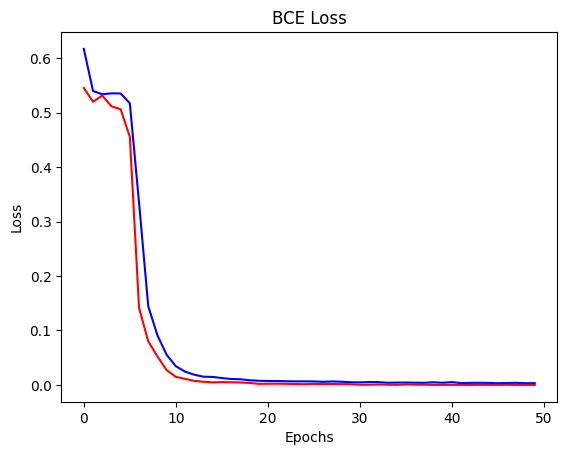

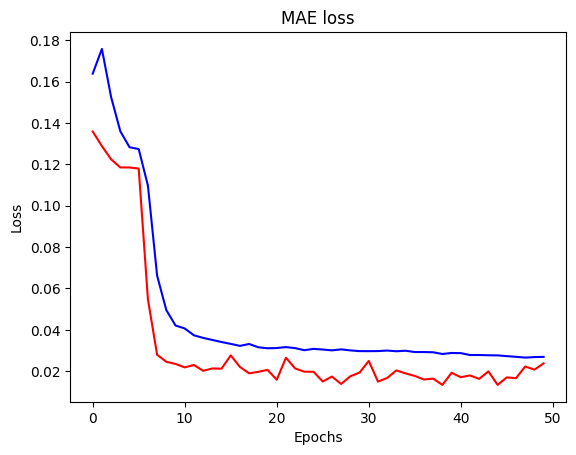

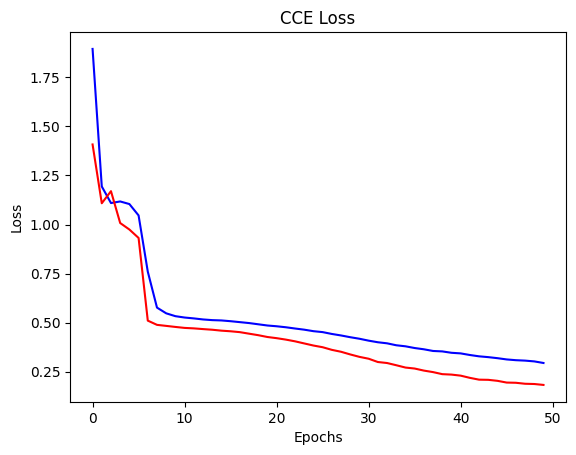

In [22]:
################ Loss/Val Loss Plots ###########
plt.figure()
plt.plot(history.history['bf_loss'], c = 'b')
plt.plot(history.history['val_bf_loss'], c = 'r')
plt.title('BCE Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')

plt.figure()
plt.plot(history.history['p_loss'], c = 'b')
plt.plot(history.history['val_p_loss'], c = 'r')
plt.title('MAE loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')

plt.figure()
plt.plot(history.history['c_loss'], c = 'b')
plt.plot(history.history['val_c_loss'], c = 'r')
plt.title('CCE Loss')
plt.ylabel('Loss')
plt.xlabel('Epochs')

In [23]:
######## Model Predictions #########
predictions = model.predict(test_imgs)
predictions = np.concatenate(predictions, axis = -1)
predicted_bboxes = [extract_bboxes_from_yolo_image(i) for i in predictions]

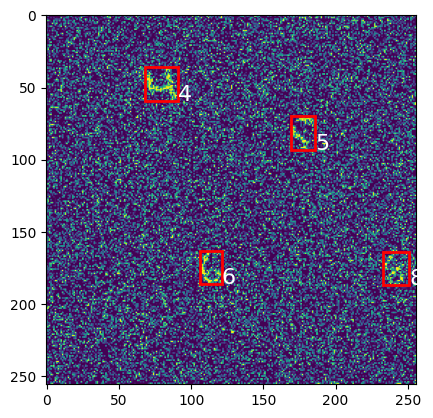

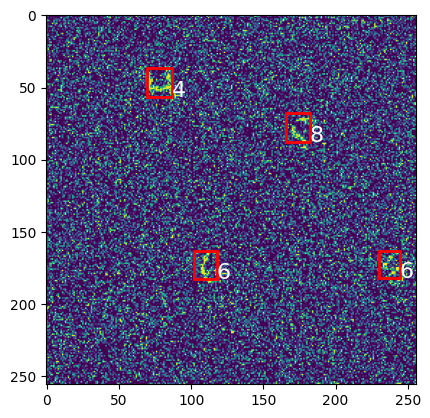

In [27]:
N = 0
plot_img_bboxes(test_imgs[N],test_bboxes[N])
plot_img_bboxes(test_imgs[N],predicted_bboxes[N])